In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')

QUESTION 1: Basic Sinusoidal Signal


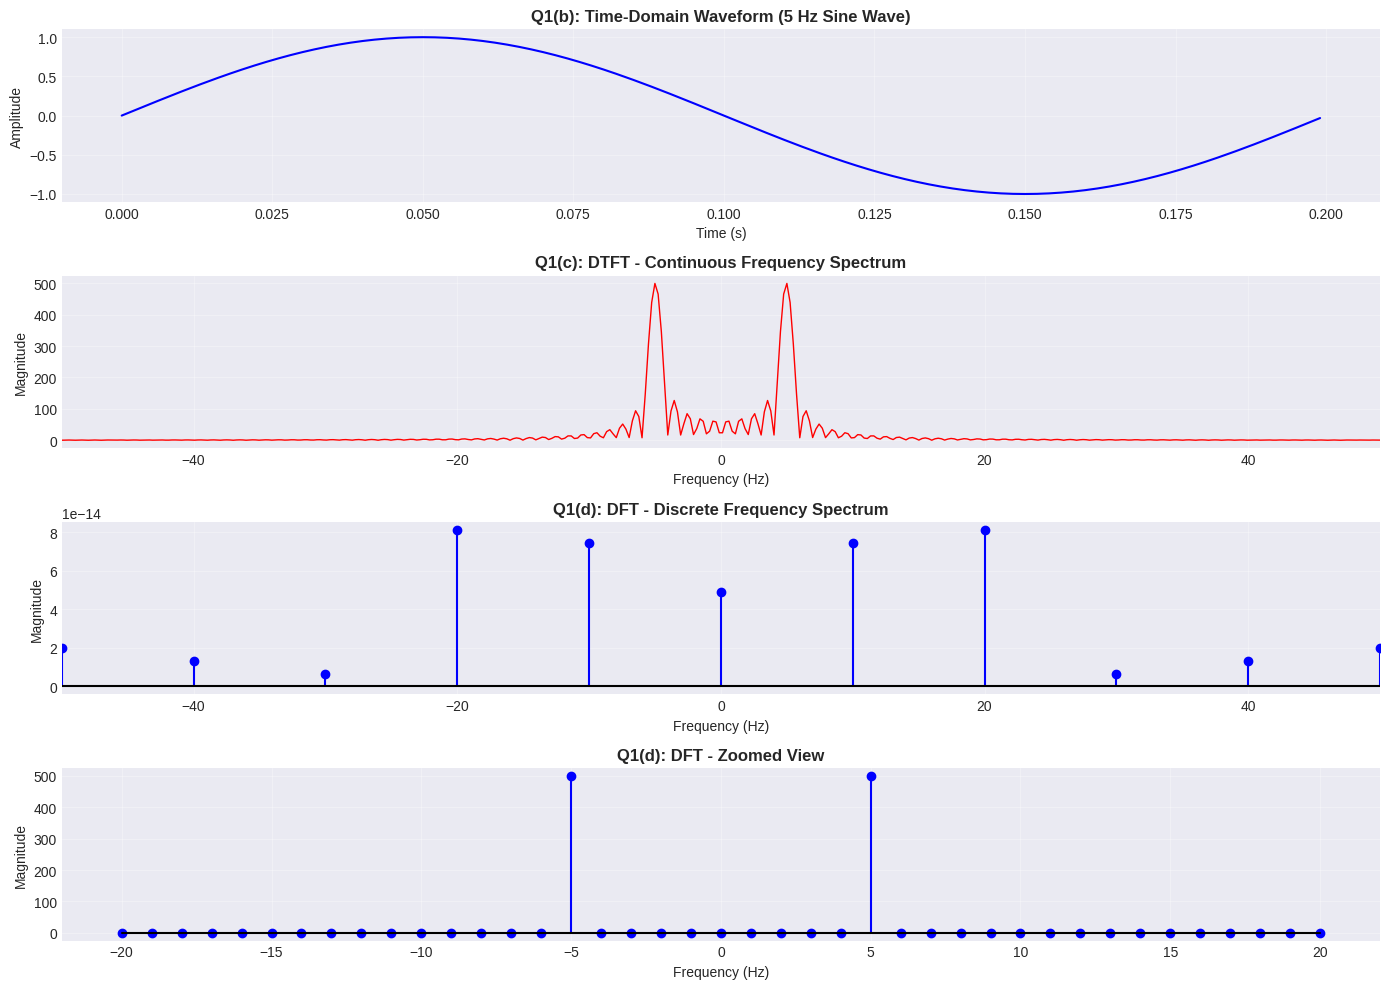

Peak frequency in DFT: 5.0 Hz



In [2]:
# ============================================================================
# QUESTION 1: Basic Sinusoidal Signal
# ============================================================================
print("=" * 60)
print("QUESTION 1: Basic Sinusoidal Signal")
print("=" * 60)

# Parameters
fs = 1000  # Sampling frequency (Hz)
f = 5      # Signal frequency (Hz)
T = 1      # Duration (seconds)
t = np.linspace(0, T, fs, endpoint=False)

# (a) Generate sinusoidal signal
signal_1 = np.sin(2 * np.pi * f * t)

# (b) Plot time-domain waveform
fig1 = plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t[:200], signal_1[:200], 'b-', linewidth=1.5)
plt.title('Q1(b): Time-Domain Waveform (5 Hz Sine Wave)', fontsize=12, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# (c) Compute and plot DTFT (continuous frequency spectrum)
N_dtft = 4096  # High resolution for DTFT
freq_dtft = np.linspace(-fs/2, fs/2, N_dtft)
omega = 2 * np.pi * freq_dtft / fs

# DTFT computation
X_dtft = np.zeros(N_dtft, dtype=complex)
for k, w in enumerate(omega):
    X_dtft[k] = np.sum(signal_1 * np.exp(-1j * w * np.arange(len(signal_1))))

magnitude_dtft = np.abs(X_dtft)

plt.subplot(4, 1, 2)
plt.plot(freq_dtft, magnitude_dtft, 'r-', linewidth=1)
plt.title('Q1(c): DTFT - Continuous Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# (d) Compute and plot DFT (discrete frequency spectrum)
X_dft = fft(signal_1)
freq_dft = fftfreq(len(signal_1), 1/fs)
magnitude_dft = np.abs(X_dft)

# Sort for plotting
sorted_indices = np.argsort(freq_dft)
freq_dft_sorted = freq_dft[sorted_indices]
magnitude_dft_sorted = magnitude_dft[sorted_indices]

plt.subplot(4, 1, 3)
plt.stem(freq_dft_sorted[::10], magnitude_dft_sorted[::10], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q1(d): DFT - Discrete Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# Zoomed view
plt.subplot(4, 1, 4)
mask = (freq_dft_sorted >= -20) & (freq_dft_sorted <= 20)
plt.stem(freq_dft_sorted[mask], magnitude_dft_sorted[mask], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q1(d): DFT - Zoomed View', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('question1_sinusoidal.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Peak frequency in DFT: {freq_dft[np.argmax(magnitude_dft[:len(magnitude_dft)//2])]} Hz")
print()







QUESTION 2: Composite Signal


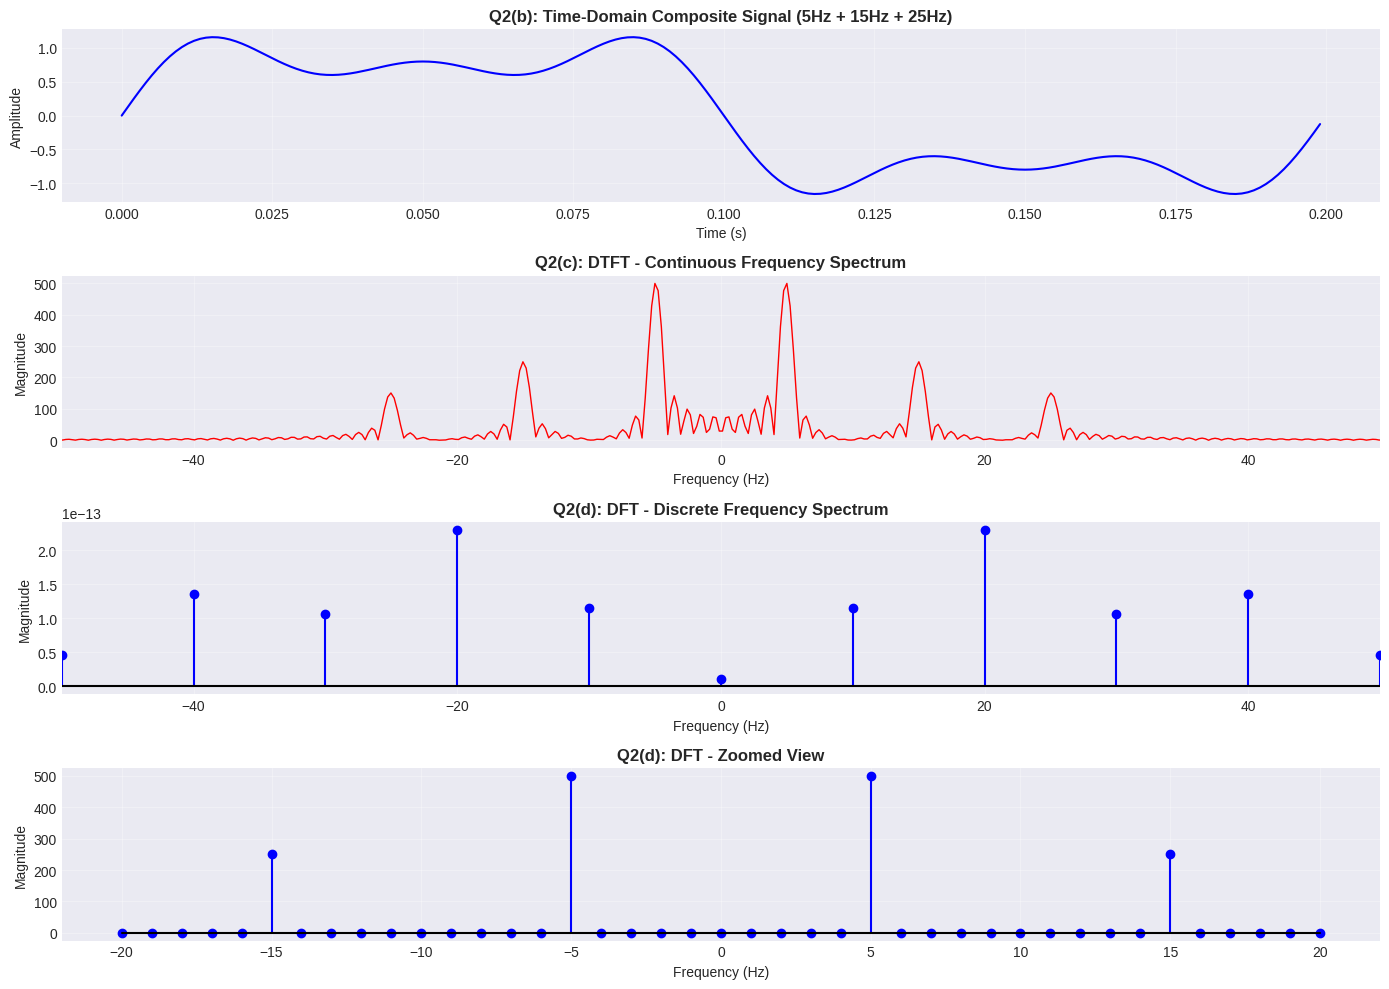

Peak frequencies in DFT: [25. 15.  5.] Hz



In [3]:
# ============================================================================
# QUESTION 2: Composite Signal
# ============================================================================
print("=" * 60)
print("QUESTION 2: Composite Signal")
print("=" * 60)

# (a) Generate composite signal
f1, f2, f3 = 5, 15, 25  # Hz
A1, A2, A3 = 1.0, 0.5, 0.3  # Amplitudes
signal_2 = A1 * np.sin(2 * np.pi * f1 * t) + \
           A2 * np.sin(2 * np.pi * f2 * t) + \
           A3 * np.sin(2 * np.pi * f3 * t)

# (b) Plot time-domain waveform
fig2 = plt.figure(figsize=(14, 10))

plt.subplot(4, 1, 1)
plt.plot(t[:200], signal_2[:200], 'b-', linewidth=1.5)
plt.title('Q2(b): Time-Domain Composite Signal (5Hz + 15Hz + 25Hz)', fontsize=12, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# (c) DTFT
X_dtft_2 = np.zeros(N_dtft, dtype=complex)
for k, w in enumerate(omega):
    X_dtft_2[k] = np.sum(signal_2 * np.exp(-1j * w * np.arange(len(signal_2))))

magnitude_dtft_2 = np.abs(X_dtft_2)

plt.subplot(4, 1, 2)
plt.plot(freq_dtft, magnitude_dtft_2, 'r-', linewidth=1)
plt.title('Q2(c): DTFT - Continuous Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# (d) DFT
X_dft_2 = fft(signal_2)
magnitude_dft_2 = np.abs(X_dft_2)
magnitude_dft_2_sorted = magnitude_dft_2[sorted_indices]

plt.subplot(4, 1, 3)
plt.stem(freq_dft_sorted[::10], magnitude_dft_2_sorted[::10], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q2(d): DFT - Discrete Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# Zoomed view
plt.subplot(4, 1, 4)
plt.stem(freq_dft_sorted[mask], magnitude_dft_2_sorted[mask], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q2(d): DFT - Zoomed View', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('question2_composite.png', dpi=300, bbox_inches='tight')
plt.show()

# Find peaks
peaks = np.argsort(magnitude_dft_2[:len(magnitude_dft_2)//2])[-3:]
print(f"Peak frequencies in DFT: {freq_dft[peaks]} Hz")
print()


QUESTION 3: Exponentially Decaying Signal


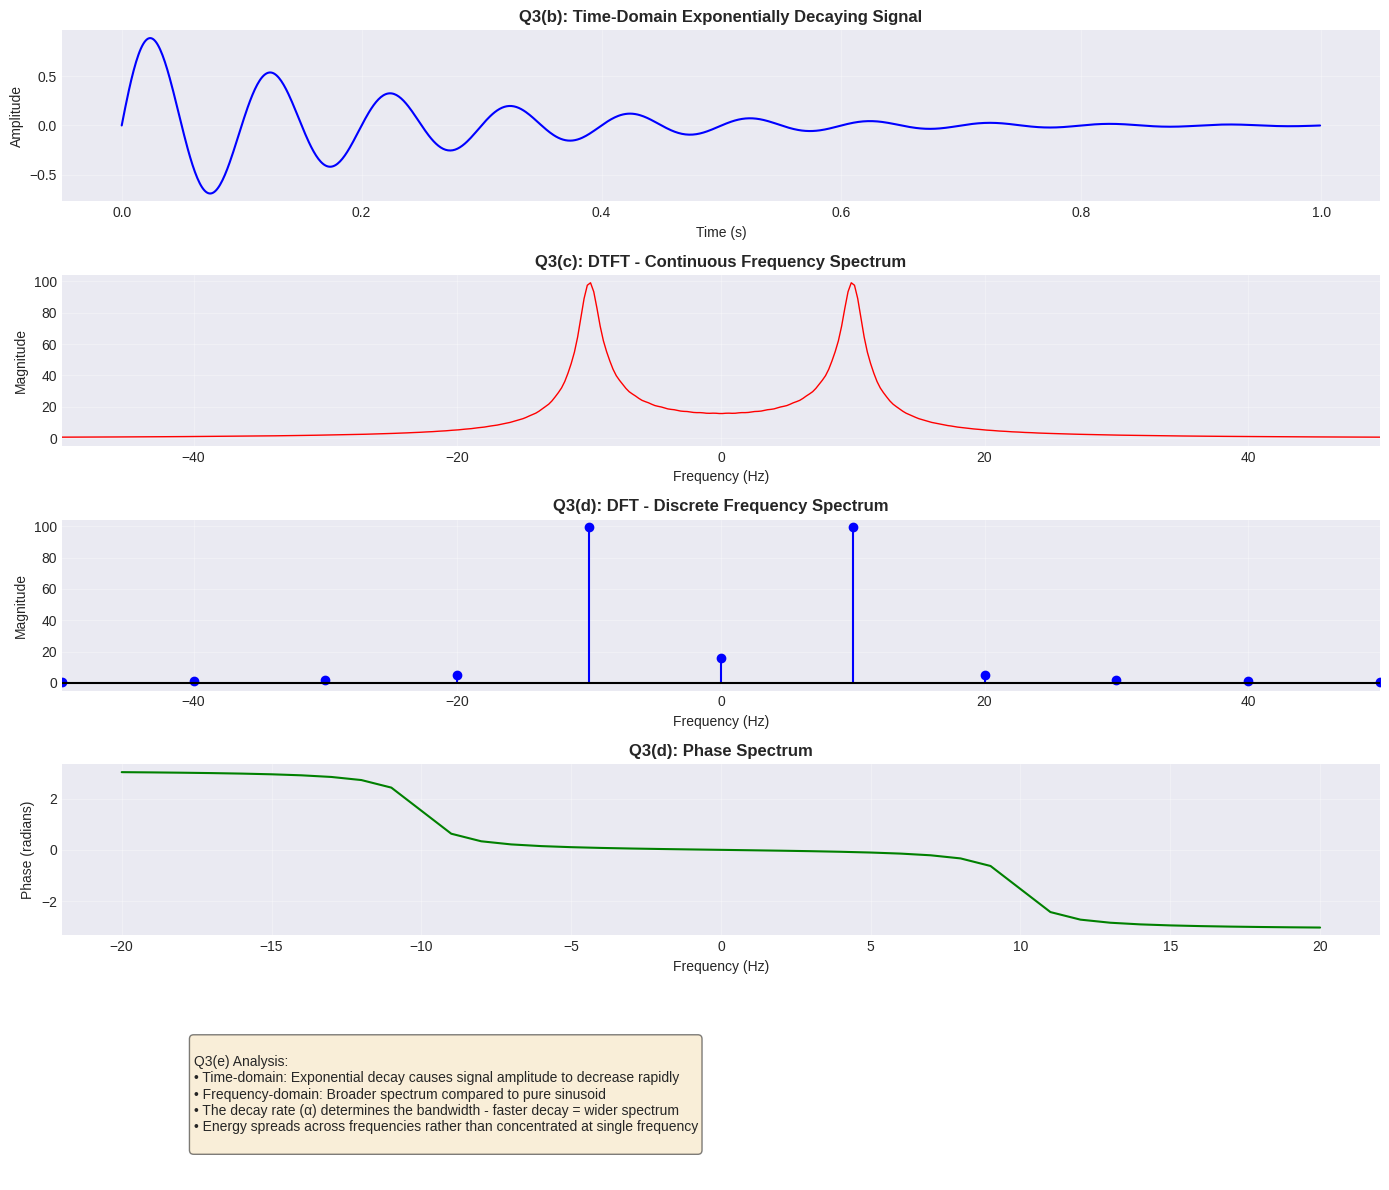


Q3(e) Analysis:
• Time-domain: Exponential decay causes signal amplitude to decrease rapidly
• Frequency-domain: Broader spectrum compared to pure sinusoid
• The decay rate (α) determines the bandwidth - faster decay = wider spectrum
• Energy spreads across frequencies rather than concentrated at single frequency



In [4]:
# ============================================================================
# QUESTION 3: Exponentially Decaying Signal
# ============================================================================
print("=" * 60)
print("QUESTION 3: Exponentially Decaying Signal")
print("=" * 60)

# (a) Generate exponentially decaying signal
alpha = 5  # Decay rate
f_exp = 10  # Frequency (Hz)
signal_3 = np.exp(-alpha * t) * np.sin(2 * np.pi * f_exp * t)

# (b) Plot time-domain waveform
fig3 = plt.figure(figsize=(14, 12))

plt.subplot(5, 1, 1)
plt.plot(t, signal_3, 'b-', linewidth=1.5)
plt.title('Q3(b): Time-Domain Exponentially Decaying Signal', fontsize=12, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# (c) DTFT
X_dtft_3 = np.zeros(N_dtft, dtype=complex)
for k, w in enumerate(omega):
    X_dtft_3[k] = np.sum(signal_3 * np.exp(-1j * w * np.arange(len(signal_3))))

magnitude_dtft_3 = np.abs(X_dtft_3)

plt.subplot(5, 1, 2)
plt.plot(freq_dtft, magnitude_dtft_3, 'r-', linewidth=1)
plt.title('Q3(c): DTFT - Continuous Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# (d) DFT
X_dft_3 = fft(signal_3)
magnitude_dft_3 = np.abs(X_dft_3)
magnitude_dft_3_sorted = magnitude_dft_3[sorted_indices]

plt.subplot(5, 1, 3)
plt.stem(freq_dft_sorted[::10], magnitude_dft_3_sorted[::10], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q3(d): DFT - Discrete Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-50, 50])

# Phase spectrum
phase_dft_3 = np.angle(X_dft_3)
phase_dft_3_sorted = phase_dft_3[sorted_indices]

plt.subplot(5, 1, 4)
plt.plot(freq_dft_sorted[mask], phase_dft_3_sorted[mask], 'g-', linewidth=1.5)
plt.title('Q3(d): Phase Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Phase (radians)')
plt.grid(True, alpha=0.3)

# (e) Analysis text
analysis_text = """
Q3(e) Analysis:
• Time-domain: Exponential decay causes signal amplitude to decrease rapidly
• Frequency-domain: Broader spectrum compared to pure sinusoid
• The decay rate (α) determines the bandwidth - faster decay = wider spectrum
• Energy spreads across frequencies rather than concentrated at single frequency
"""
plt.subplot(5, 1, 5)
plt.text(0.1, 0.5, analysis_text, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.axis('off')

plt.tight_layout()
plt.savefig('question3_exponential.png', dpi=300, bbox_inches='tight')
plt.show()

print(analysis_text)

QUESTION 4: Rectangular Pulse Signal


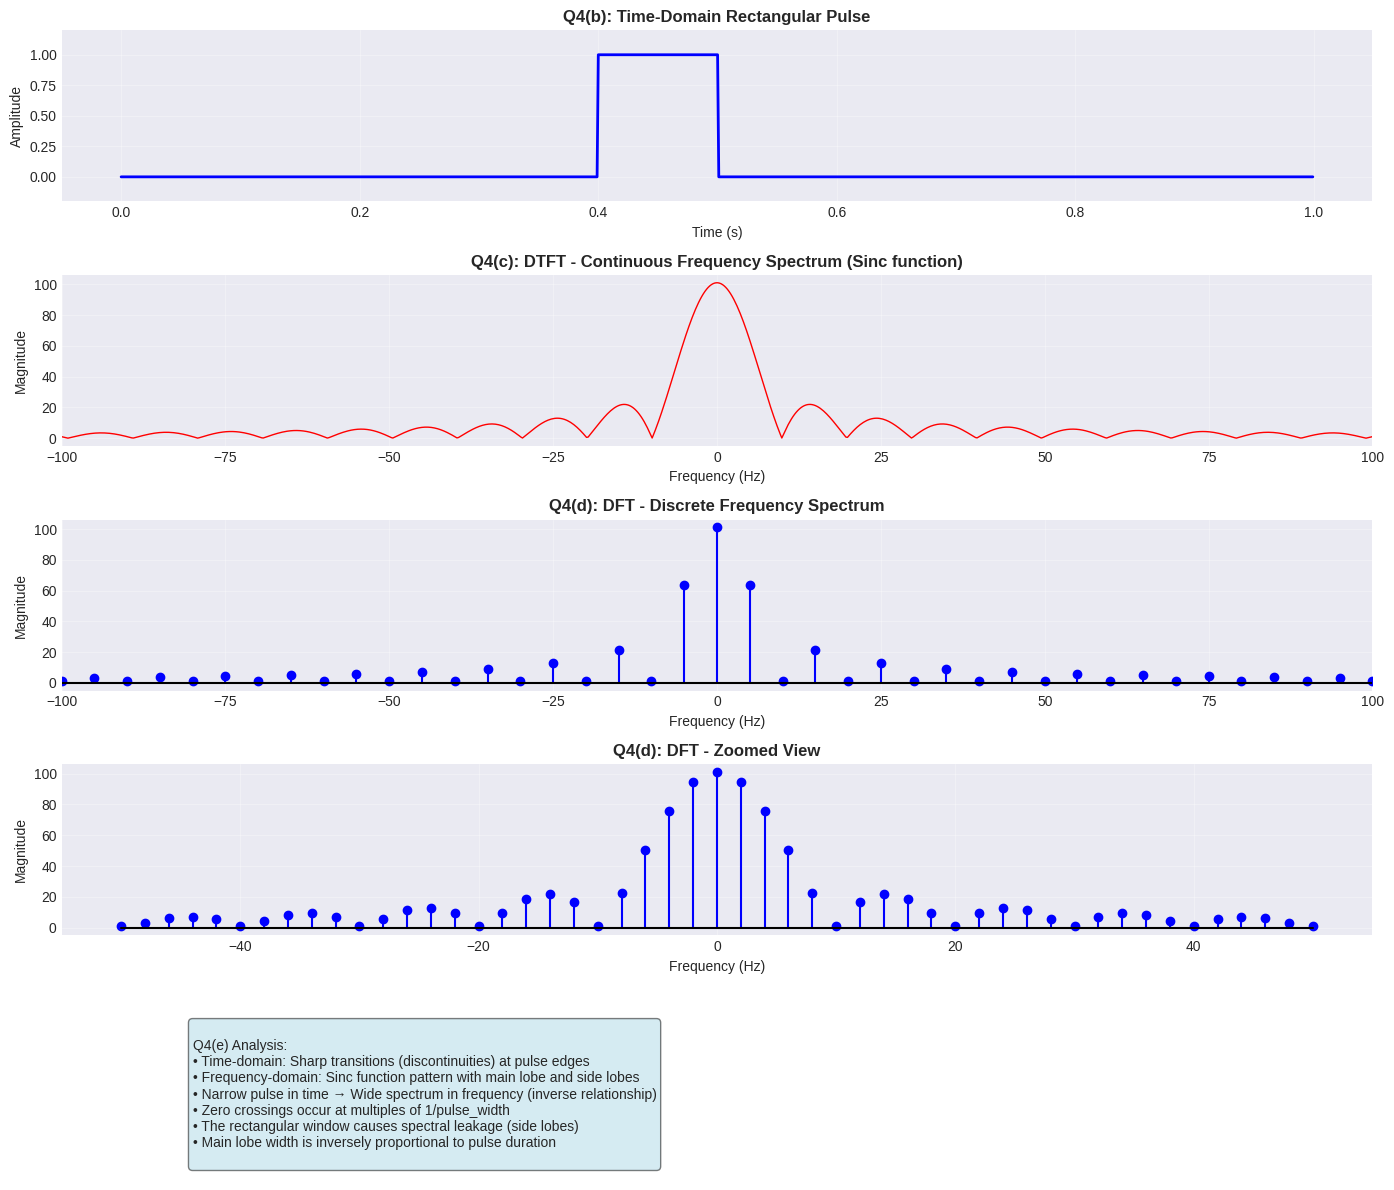


Q4(e) Analysis:
• Time-domain: Sharp transitions (discontinuities) at pulse edges
• Frequency-domain: Sinc function pattern with main lobe and side lobes
• Narrow pulse in time → Wide spectrum in frequency (inverse relationship)
• Zero crossings occur at multiples of 1/pulse_width
• The rectangular window causes spectral leakage (side lobes)
• Main lobe width is inversely proportional to pulse duration



In [5]:
# ============================================================================
# QUESTION 4: Rectangular Pulse Signal
# ============================================================================
print("=" * 60)
print("QUESTION 4: Rectangular Pulse Signal")
print("=" * 60)

# (a) Generate rectangular pulse
pulse_width = 0.1  # seconds
signal_4 = np.zeros_like(t)
pulse_indices = (t >= 0.4) & (t <= 0.4 + pulse_width)
signal_4[pulse_indices] = 1.0

# (b) Plot time-domain waveform
fig4 = plt.figure(figsize=(14, 12))

plt.subplot(5, 1, 1)
plt.plot(t, signal_4, 'b-', linewidth=2)
plt.title('Q4(b): Time-Domain Rectangular Pulse', fontsize=12, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.ylim([-0.2, 1.2])

# (c) DTFT
X_dtft_4 = np.zeros(N_dtft, dtype=complex)
for k, w in enumerate(omega):
    X_dtft_4[k] = np.sum(signal_4 * np.exp(-1j * w * np.arange(len(signal_4))))

magnitude_dtft_4 = np.abs(X_dtft_4)

plt.subplot(5, 1, 2)
plt.plot(freq_dtft, magnitude_dtft_4, 'r-', linewidth=1)
plt.title('Q4(c): DTFT - Continuous Frequency Spectrum (Sinc function)', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-100, 100])

# (d) DFT
X_dft_4 = fft(signal_4)
magnitude_dft_4 = np.abs(X_dft_4)
magnitude_dft_4_sorted = magnitude_dft_4[sorted_indices]

plt.subplot(5, 1, 3)
plt.stem(freq_dft_sorted[::5], magnitude_dft_4_sorted[::5], linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q4(d): DFT - Discrete Frequency Spectrum', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)
plt.xlim([-100, 100])

# Zoomed view
mask_wide = (freq_dft_sorted >= -50) & (freq_dft_sorted <= 50)
plt.subplot(5, 1, 4)
plt.stem(freq_dft_sorted[mask_wide][::2], magnitude_dft_4_sorted[mask_wide][::2],
         linefmt='b-', markerfmt='bo', basefmt='k-')
plt.title('Q4(d): DFT - Zoomed View', fontsize=12, fontweight='bold')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)

# (e) Analysis text
analysis_text_4 = """
Q4(e) Analysis:
• Time-domain: Sharp transitions (discontinuities) at pulse edges
• Frequency-domain: Sinc function pattern with main lobe and side lobes
• Narrow pulse in time → Wide spectrum in frequency (inverse relationship)
• Zero crossings occur at multiples of 1/pulse_width
• The rectangular window causes spectral leakage (side lobes)
• Main lobe width is inversely proportional to pulse duration
"""
plt.subplot(5, 1, 5)
plt.text(0.1, 0.5, analysis_text_4, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
plt.axis('off')

plt.tight_layout()
plt.savefig('question4_rectangular.png', dpi=300, bbox_inches='tight')
plt.show()

print(analysis_text_4)


In [6]:
# ============================================================================
# Summary Comparison
# ============================================================================
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print("""
Key Observations:
1. Pure Sinusoid: Single frequency component (impulse in frequency domain)
2. Composite Signal: Multiple discrete frequency components
3. Exponential Decay: Broader frequency spectrum due to time-domain decay
4. Rectangular Pulse: Sinc function spectrum with main and side lobes

DTFT vs DFT:
• DTFT: Continuous frequency representation (high resolution)
• DFT: Discrete samples of DTFT (practical implementation)
• DFT is computed using FFT algorithm for efficiency
""")

print("\nAll plots have been saved as PNG files.")
print("Execution complete!")

SUMMARY

Key Observations:
1. Pure Sinusoid: Single frequency component (impulse in frequency domain)
2. Composite Signal: Multiple discrete frequency components
3. Exponential Decay: Broader frequency spectrum due to time-domain decay
4. Rectangular Pulse: Sinc function spectrum with main and side lobes

DTFT vs DFT:
• DTFT: Continuous frequency representation (high resolution)
• DFT: Discrete samples of DTFT (practical implementation)
• DFT is computed using FFT algorithm for efficiency


All plots have been saved as PNG files.
Execution complete!
